In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [108]:
data =pd.read_csv('winequality-red.csv')
data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [109]:
data.shape

(1599, 12)

In [110]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [111]:
data.info

<bound method DataFrame.info of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1594            6.2             0.600         0.08             2.0      0.090   
1595            5.9             0.550         0.10             2.2      0.062   
1596            6.3             0.510         0.13             2.3      0.076   
1597            5.9             0.645         0.12             2.0      0.075   
1598            6.0             0.310         0.47             3.6      0.067

In [112]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [113]:
data=data.drop_duplicates()
data.shape

(1359, 12)

In [114]:
data.quality.value_counts()

5    577
6    535
7    167
4     53
8     17
3     10
Name: quality, dtype: int64

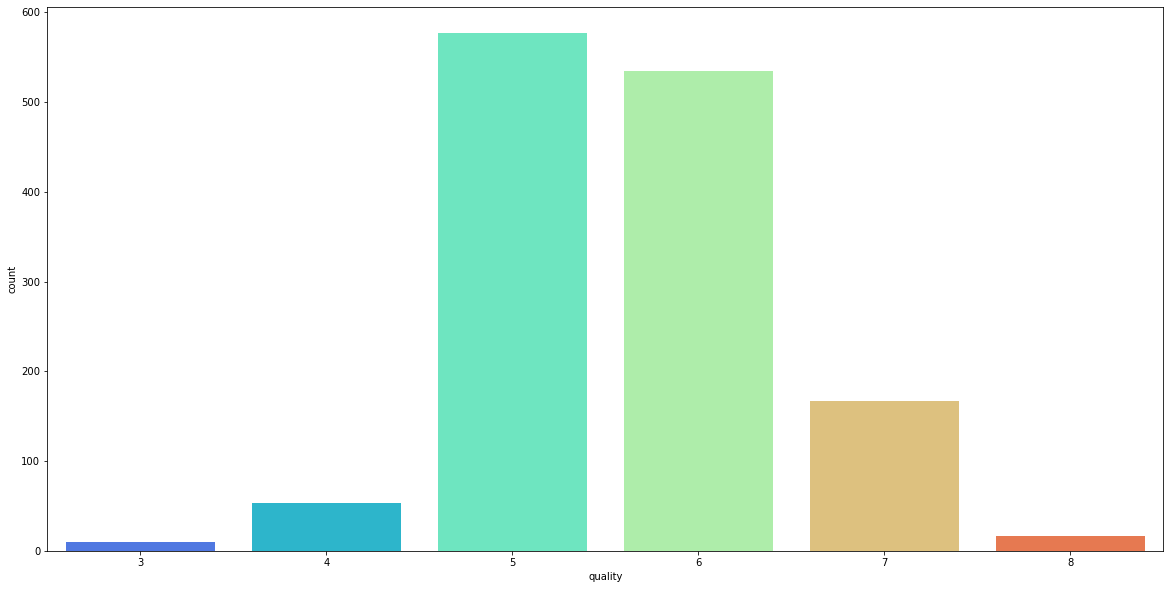

In [115]:
plt.figure(figsize=(20,10))
sns.countplot(x ='quality',data=data,palette='rainbow')
plt.show()

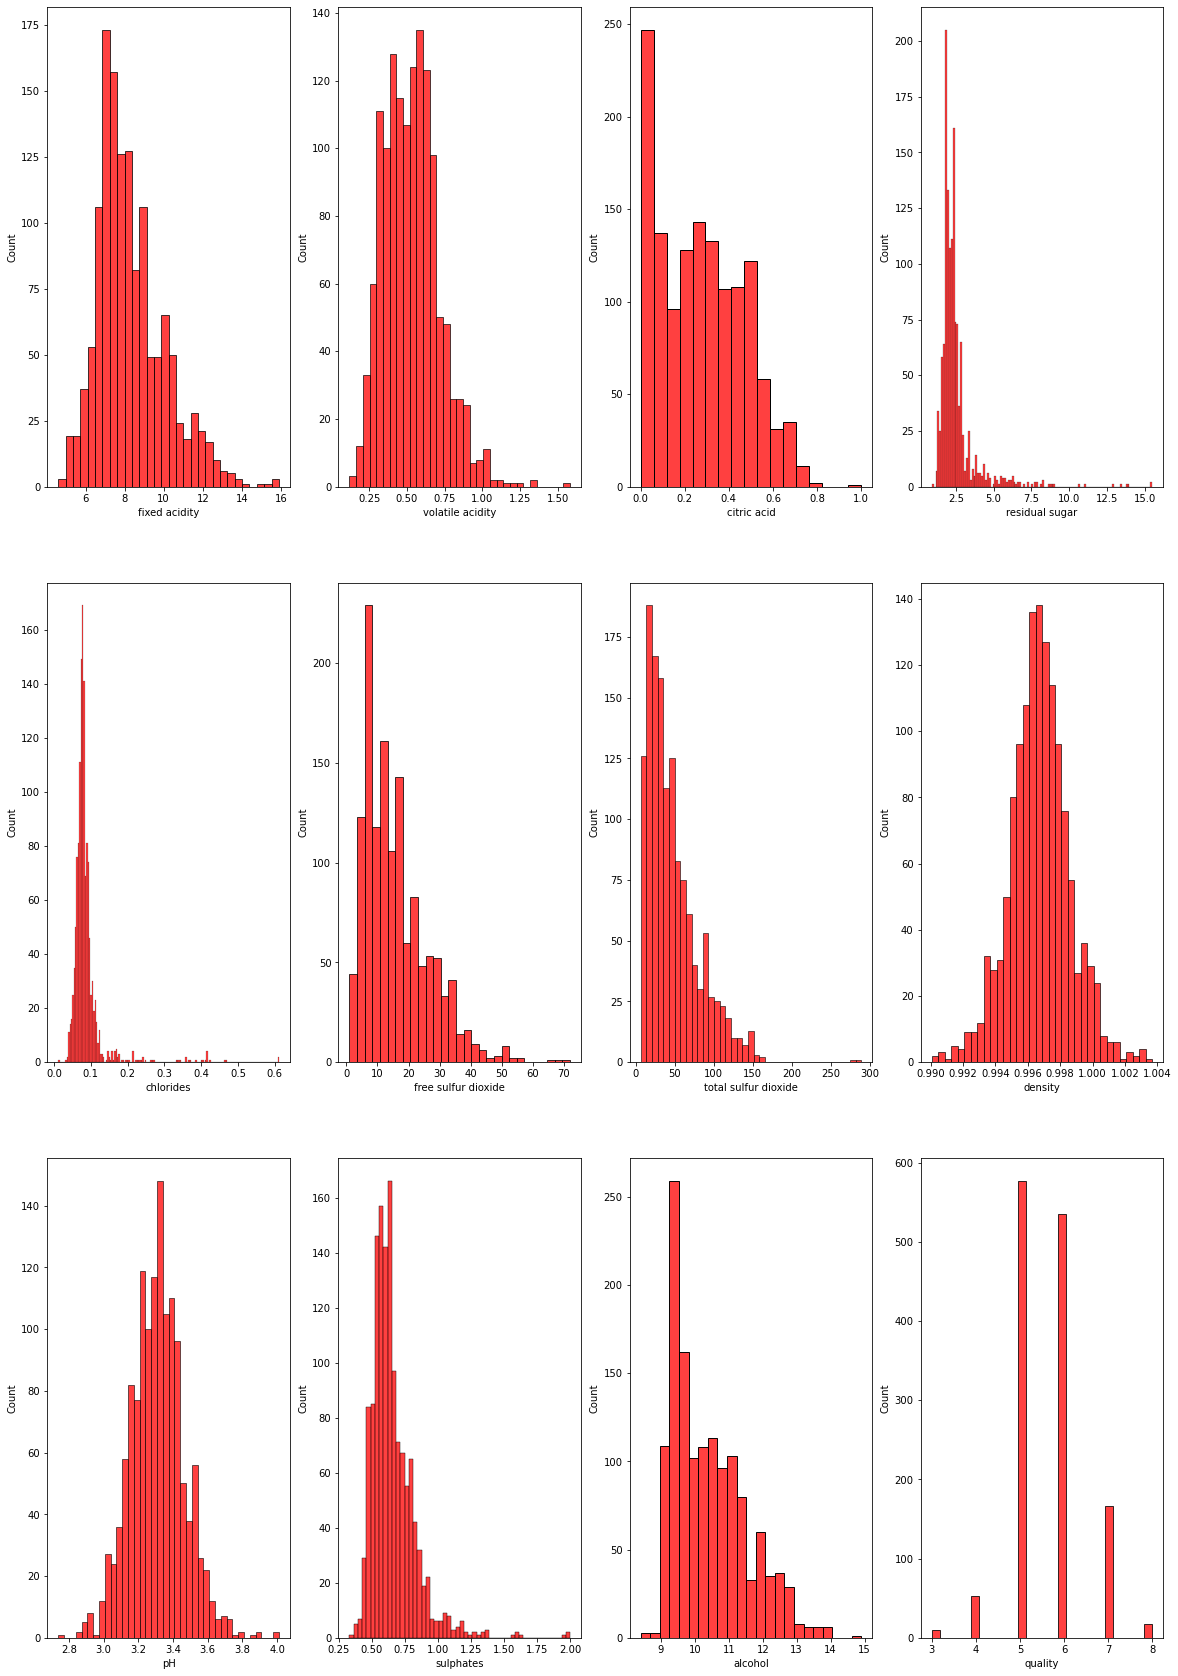

In [116]:
color = sns.color_palette("pastel")

fig, ax1 = plt.subplots(3,4, figsize=(20,30))
k = 0
columns = list(data.columns)
for i in range(3):
    for j in range(4):
            sns.histplot(data[columns[k]], ax = ax1[i][j], color = 'red')
            k += 1
plt.show()

recudial sugar,cholorides,free sulpur dioxide,sulpates,totalsulpurdioxide

In [117]:
data.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')

In [118]:
data['residual sugar']=np.log(data['residual sugar'])
data['chlorides']=np.log(data['chlorides'])
data['free sulfur dioxide']=np.log(data['free sulfur dioxide'])
data['total sulfur dioxide']=np.log(data['total sulfur dioxide'])
data['sulphates']=np.log(data['sulphates'])

In [119]:
data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

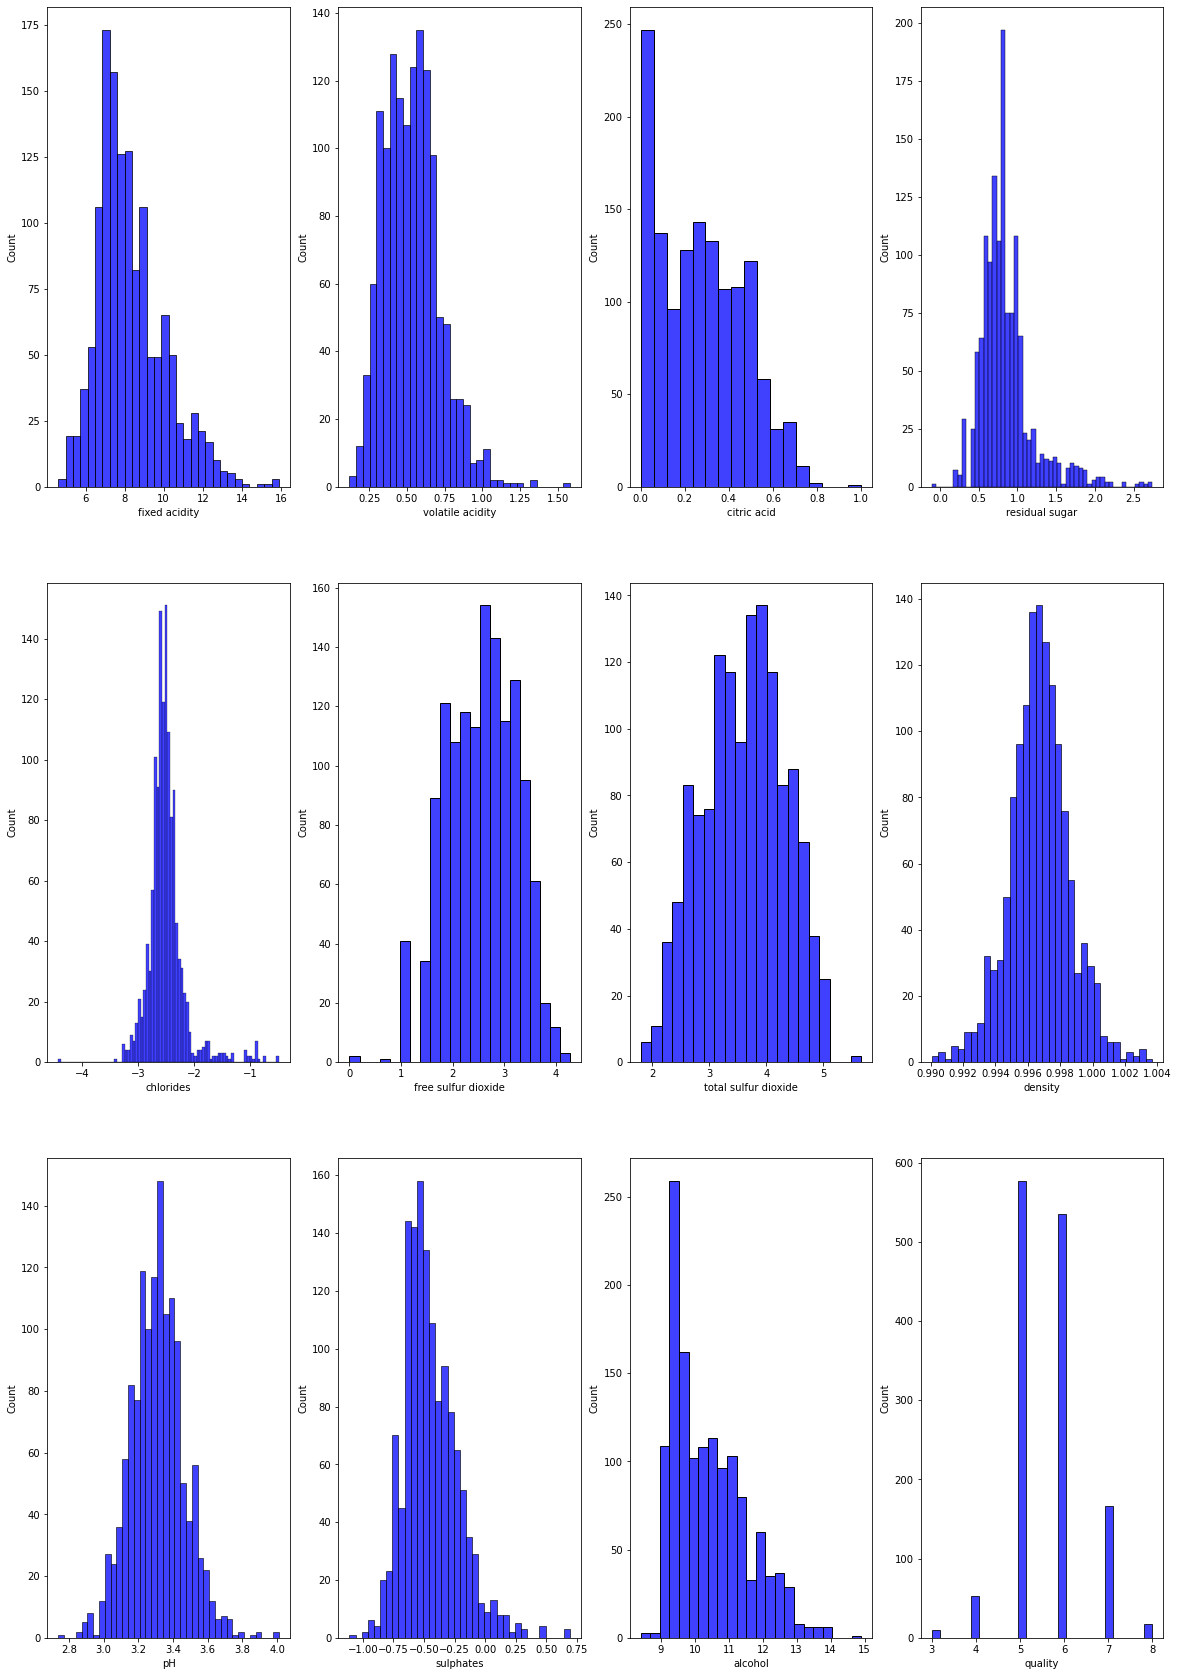

In [120]:
color = sns.color_palette("pastel")

fig, ax1 = plt.subplots(3,4, figsize=(20,30))
k = 0
columns = list(data.columns)
for i in range(3):
    for j in range(4):
            sns.histplot(data[columns[k]], ax = ax1[i][j], color = 'blue')
            k += 1
plt.show()

In [121]:
x=data.drop('quality',axis=1)
x.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.4,0.70,0.00,0.641854,-2.577022,2.397895,3.526361,0.9978,3.51,-0.579818,9.4
1,7.8,0.88,0.00,0.955511,-2.322788,3.218876,4.204693,0.9968,3.20,-0.385662,9.8
2,7.8,0.76,0.04,0.832909,-2.385967,2.708050,3.988984,0.9970,3.26,-0.430783,9.8
3,11.2,0.28,0.56,0.641854,-2.590267,2.833213,4.094345,0.9980,3.16,-0.544727,9.8
5,7.4,0.66,0.00,0.587787,-2.590267,2.564949,3.688879,0.9978,3.51,-0.579818,9.4


In [122]:
y=data['quality']
y.head()

0    5
1    5
2    5
3    6
5    5
Name: quality, dtype: int64

In [123]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1087, 11), (272, 11), (1087,), (272,))

In [124]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

print("After SMOTE:", Counter(y_resampled))

After SMOTE: Counter({6: 458, 5: 458, 4: 458, 7: 458, 8: 458, 3: 458})


In [125]:
x_resampled.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,2748.000000,2748.000000,2748.000000,2748.000000,2748.000000,2748.000000,2748.000000,2748.000000,2748.000000,2748.000000,2748.000000
mean,8.464334,0.566453,0.285679,0.835309,-2.485022,2.413026,3.345375,0.996570,3.321753,-0.433571,10.691615
std,1.628191,0.234911,0.191850,0.310888,0.306133,0.642093,0.673103,0.001878,0.147420,0.218111,1.187803
min,4.600000,0.160000,0.000000,-0.105361,-4.422849,0.000000,1.791759,0.990070,2.740000,-0.994252,8.400000
25%,7.310224,0.390000,0.106654,0.641854,-2.652303,1.798634,2.772589,0.995259,3.222994,-0.585645,9.700000
50%,8.196674,0.528227,0.294672,0.771789,-2.534865,2.397895,3.326868,0.996566,3.314176,-0.446287,10.549887
75%,9.510814,0.680000,0.439243,0.946521,-2.383201,2.890372,3.850148,0.997828,3.412639,-0.287857,11.539402
max,15.900000,1.580000,1.000000,2.740840,-0.494296,4.276666,5.666427,1.003200,4.010000,0.693147,14.900000


In [126]:
#rescale
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_fit=scaler.fit_transform(x_resampled)
x_test=scaler.transform(x_test)

In [127]:
x_train_fit_data=pd.DataFrame (x_train_fit ,columns = x_resampled.columns)
x_train_fit_data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
count,2.748000e+03,2.748000e+03,2.748000e+03,2.748000e+03,2.748000e+03,2.748000e+03,2.748000e+03,2.748000e+03,2.748000e+03,2.748000e+03,2.748000e+03
mean,-5.871900e-16,-2.745459e-16,-1.186985e-16,2.698795e-17,-6.540438e-16,1.722300e-16,-2.028541e-16,4.677917e-14,2.054640e-15,-1.913195e-16,-4.654210e-17
std,1.000182e+00,1.000182e+00,1.000182e+00,1.000182e+00,1.000182e+00,1.000182e+00,1.000182e+00,1.000182e+00,1.000182e+00,1.000182e+00,1.000182e+00
min,-2.373822e+00,-1.730554e+00,-1.489343e+00,-3.026306e+00,-6.331165e+00,-3.758750e+00,-2.308558e+00,-3.460963e+00,-3.946956e+00,-2.571091e+00,-1.929639e+00
25%,-7.089586e-01,-7.512836e-01,-9.333203e-01,-6.223817e-01,-5.465315e-01,-9.570326e-01,-8.511183e-01,-6.978887e-01,-6.700405e-01,-6.973592e-01,-8.349828e-01
50%,-1.644207e-01,-1.627553e-01,4.688666e-02,-2.043583e-01,-1.628464e-01,-2.356922e-02,-2.750003e-02,-2.237413e-03,-5.140716e-02,-5.831150e-02,-1.193411e-01
75%,6.428429e-01,4.834490e-01,8.005827e-01,3.577862e-01,3.326621e-01,7.435571e-01,7.500546e-01,6.699034e-01,6.166229e-01,6.681933e-01,7.138734e-01
max,4.567657e+00,4.315377e+00,3.724004e+00,6.130438e+00,6.503991e+00,2.902976e+00,3.448911e+00,3.530220e+00,4.669472e+00,5.166742e+00,3.543643e+00


In [128]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_fit = scaler.fit_transform(x_resampled)
x_test = scaler.transform(x_test)

### linear regression


In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
model_lr = LogisticRegression()
model_lr.fit(x_train_fit, y_resampled)
y_pred_lr = model_lr.predict(x_test)
accuracy_lr = accuracy_score(y_test,y_pred_lr)
print("Accuracy of LR:", round(accuracy_lr, 2)*100,"%")

Accuracy of LR: 5.0 %


### svm

In [130]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
model_SVC =SVC()
model_SVC.fit(x_train_fit,y_resampled)
y_pred_SVC=model_lr.predict(x_test)
accuracy_SVC=accuracy_score(y_test,y_pred_lr)
print("Accuracy of SVC:" ,round(accuracy_lr,2)*100,"%")

Accuracy of SVC: 5.0 %


### desicion tree

In [131]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
model_dt = DecisionTreeClassifier()
model_dt.fit(x_train_fit,y_resampled)
y_pred_dt=model_lr.predict(x_test)
accuracy_dt=accuracy_score(y_test,y_pred_lr)
print("Accuracy of DT:" ,round(accuracy_lr,2)*100,"%")

Accuracy of DT: 5.0 %


### knn

In [132]:
from sklearn.neighbors import KNeighborsClassifier
model_Knn = KNeighborsClassifier()
model_Knn.fit(x_train_fit,y_resampled)
y_pred_Knn=model_lr.predict(x_test)
accuracy_Knn=accuracy_score(y_test,y_pred_lr)
print("Accuracy of KNN:" ,round(accuracy_lr,2)*100,"%")

Accuracy of KNN: 5.0 %


### random forest

In [133]:
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
model_rf.fit(x_train_fit,y_resampled)
y_pred_rf=model_lr.predict(x_test)
accuracy_rf=accuracy_score(y_test,y_pred_lr)
print("Accuracy of RF:" ,round(accuracy_lr,2)*100,"%")

Accuracy of RF: 5.0 %


In [134]:
## save rf model and scaler parameters
import pickle
pickle.dump(model_rf, open('model_rf.pkl', 'wb'))
pickle.dump(scaler, open('scaler.pkl', 'wb'))

In [ ]:
import numpy as np
import pickle

# Load saved model and scaler
with open("model_rf.pkl", "rb") as f:
    model = pickle.load(f)

with open("scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

# List of feature names in correct order
feature_names = [
    'fixed acidity', 'volatile acidity', 'citric acid', 
    'residual sugar','chlorides', 'free sulfur dioxide', 
    'total sulfur dioxide', 'density',0.
    'pH', 'sulphates', 'alcohol'
]

# Collect input values from user
print("Enter the following details for prediction:")

user_values = []
for feature in feature_names:
    val = float(input(f"Enter {feature}: "))
    user_values.append(val)

# Convert to array and reshape
input_data = np.array(user_values).reshape(1, -1)

# Scale using the fitted scaler
scaled_data = scaler.transform(input_data)

# Predict
prediction = model.predict(scaled_data)

print(f"\nPredicted Wine Quality: {prediction[0]}")

Enter the following details for prediction:

Predicted Wine Quality: 5
